# 23. Прогноз продаж: 50 магазинов × 2 года, признаки из прошлого и разбиение по времени

| | |
|---|---|
| **Уровень** | 4 из 4 — большие данные и сложные задачи (`4_large`) |
| **Скрипт-источник** | [`23_time_series_forecasting.py`](../23_time_series_forecasting.py) — тот же код, запуск из терминала |
| **Время выполнения** | ≈ 8 с |

**Цель.** Построить прогноз временного ряда бустингом и не обмануть себя утечкой из будущего.

### Чему вы научитесь

- Превращать ряд в табличную задачу: лаги, скользящие средние, календарь, праздники
- Горизонт прогноза — лаги не короче горизонта
- Разбиение по времени
- Метрика WAPE
- Наивный прогноз как база
- Потеря Пуассона для продаж
- Как утечка из будущего завышает качество

### Данные

`_data.make_store_sales` — 50 магазинов × 730 дней = 36 500 строк: дата, магазин, тип, промо, праздник, температура, продажи (недельная и годовая сезонность, праздники, промо, тренд).

### План

1. **Этап 1.** Данные
2. **Этап 2.** Признаки только из прошлого: лаги не короче горизонта, скользящие средние со сдвигом, календарь
3. **Этап 3.** Разбиение по времени: обучение → 60 дней валидации → последние 60 дней теста
4. **Этап 4.** WAPE = Σ|ошибка| / Σ продаж на тесте
5. **Этап 5.** Две ошибки, которые завышают качество
6. **Этап 6.** Что использует модель и как выглядит прогноз одного магазина
7. **Этап 7.** Выводы

> Ноутбук собран из `examples/4_large/23_time_series_forecasting.py` командой `python examples/build_notebooks.py`. Чтобы изменить пример, правьте скрипт и пересоберите ноутбук.

## Подготовка

Ячейка ниже находит папку `examples/` (ноутбук можно открыть из любой рабочей папки внутри
репозитория), подключает общий каркас примеров `_common.Example` и учебную библиотеку курса
`gbcourse`. Каркас печатает этапы и выводы, «раскрывает» датасет и показывает графики прямо в
ноутбуке. Выполняйте ячейки сверху вниз: **Run → Run All Cells**.

In [1]:
import sys
from pathlib import Path

EXAMPLES = next(p / "examples" for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "examples" / "_common.py").is_file())
sys.path.insert(0, str(EXAMPLES))
from _common import Example
from _data import make_store_sales

ex = Example(EXAMPLES / "4_large/23_time_series_forecasting.py", title="23. Прогноз продаж: временной ряд бустингом",
             goal="прогнозировать ряд на неделю вперёд без утечки из будущего")

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gbcourse import plotting

HORIZON = 7                                                   # прогнозируем на 7 дней вперёд

## Этап 1. Данные

In [2]:
df = make_store_sales(50, 730).sort_values(["магазин", "дата"]).reset_index(drop=True)
ex.describe(df.drop(columns="продажи"), df["продажи"].to_numpy(), target="продажи",
            source="examples/_data.py → make_store_sales")
print(f"   период: {df['дата'].min():%Y-%m-%d} … {df['дата'].max():%Y-%m-%d}")

   Источник: examples/_data.py → make_store_sales
   Объектов: 36 500   признаков: 6   память: 1.43 МБ
   Типы признаков: int64 × 3, datetime64[us] × 1, category × 1, float64 × 1
   Пропусков нет
   Цель «продажи»: среднее 77.145, σ 35.884, мин 6.000, макс 349.000
   Первые строки:


,дата,магазин,тип,промо,праздник,температура,[продажи]
0,2023-01-01,0,центр,0,1,-13.9,21
1,2023-01-02,0,центр,0,0,-14.1,74
2,2023-01-03,0,центр,1,0,-8.4,109


   период: 2023-01-01 … 2024-12-30


## Этап 2. Признаки только из прошлого: лаги не короче горизонта, скользящие средние со сдвигом, календарь

In [3]:
g = df.groupby("магазин")["продажи"]
for lag in (7, 14, 28):
    df[f"лаг_{lag}"] = g.shift(lag)
df["среднее7_лаг7"] = g.transform(lambda s: s.shift(HORIZON).rolling(7).mean())
df["среднее28_лаг7"] = g.transform(lambda s: s.shift(HORIZON).rolling(28).mean())
df["день_недели"] = df["дата"].dt.dayofweek
df["месяц"] = df["дата"].dt.month
df["день_года"] = df["дата"].dt.dayofyear
df["канун_праздника"] = df.groupby("магазин")["праздник"].shift(-1).fillna(0)   # календарь известен заранее
df = df.dropna(subset=["среднее28_лаг7"]).copy()
df["магазин"] = df["магазин"].astype("category")
F = ["магазин", "тип", "промо", "праздник", "канун_праздника", "температура", "лаг_7", "лаг_14", "лаг_28",
     "среднее7_лаг7", "среднее28_лаг7", "день_недели", "месяц", "день_года"]
print(f"   признаков {len(F)}; строк после отбрасывания первых 34 дней каждого магазина: {len(df)}")
ex.note(f"""Лаг короче горизонта ({HORIZON} дней) использовать нельзя: в момент прогноза этих продаж ещё не было.
Промо, праздники и температуру (прогноз погоды) считаем известными заранее — это нужно проверять в реальном проекте.""")

   признаков 14; строк после отбрасывания первых 34 дней каждого магазина: 34800


> ▸ **Вывод.** Лаг короче горизонта (7 дней) использовать нельзя: в момент прогноза этих продаж ещё не было. Промо, праздники и температуру (прогноз погоды) считаем известными заранее — это нужно проверять в реальном проекте.

## Этап 3. Разбиение по времени: обучение → 60 дней валидации → последние 60 дней теста

In [4]:
end = df["дата"].max()
cut, vcut = end - pd.Timedelta(days=60), end - pd.Timedelta(days=120)
tr, va, te = df[df["дата"] <= vcut], df[(df["дата"] > vcut) & (df["дата"] <= cut)], df[df["дата"] > cut]
print(f"   обучение до {vcut:%Y-%m-%d} ({len(tr)}), валидация ({len(va)}), тест с {cut + pd.Timedelta(days=1):%Y-%m-%d} ({len(te)})")
wape = lambda y, p: float(np.sum(np.abs(y - p)) / np.sum(y))


def fit(train, valid, feats, **kw):
    m = lgb.LGBMRegressor(n_estimators=3000, learning_rate=0.03, num_leaves=63, verbose=-1, random_state=0, **kw)
    m.fit(train[feats], train["продажи"], eval_X=(valid[feats],), eval_y=(valid["продажи"],),
          callbacks=[lgb.early_stopping(100, verbose=False)])
    return m

   обучение до 2024-09-01 (28800), валидация (3000), тест с 2024-11-01 (3000)


## Этап 4. WAPE = Σ|ошибка| / Σ продаж на тесте

In [5]:
naive = wape(te["продажи"], te["лаг_7"])
m_l2 = fit(tr, va, F)
m_po = fit(tr, va, F, objective="poisson")
p_l2, p_po = m_l2.predict(te[F]), m_po.predict(te[F])
print(f"   наивный прогноз «как неделю назад»   {naive:.4f}")
print(f"   LightGBM, MSE                       {wape(te['продажи'], p_l2):.4f}  (деревьев {m_l2.best_iteration_})")
print(f"   LightGBM, Пуассон                   {wape(te['продажи'], p_po):.4f}  (деревьев {m_po.best_iteration_})")
assert wape(te["продажи"], p_po) < naive
ex.note("Бустинг снижает ошибку наивного прогноза почти вдвое. Пуассон — естественная потеря для счётных продаж.")

   наивный прогноз «как неделю назад»   0.1787
   LightGBM, MSE                       0.1025  (деревьев 417)
   LightGBM, Пуассон                   0.1017  (деревьев 820)


> ▸ **Вывод.** Бустинг снижает ошибку наивного прогноза почти вдвое. Пуассон — естественная потеря для счётных продаж.

## Этап 5. Две ошибки, которые завышают качество

In [6]:
leak = df.assign(среднее7_сегодня=g.transform(lambda s: s.rolling(7).mean()).loc[df.index])
FL = F + ["среднее7_сегодня"]
trL, vaL, teL = leak.loc[tr.index], leak.loc[va.index], leak.loc[te.index]
m_leak = fit(trL, vaL, FL, objective="poisson")
print(f"   а) признак «среднее за 7 дней, включая сегодня»: WAPE {wape(te['продажи'], m_leak.predict(teL[FL])):.4f}"
      " — выглядит лучше, но в момент прогноза недоступен")
perm = np.random.default_rng(0).permutation(len(df))
a, b = df.iloc[perm[: int(0.8 * len(df))]], df.iloc[perm[int(0.8 * len(df)):]]
m_rand = lgb.LGBMRegressor(n_estimators=m_po.best_iteration_, learning_rate=0.03, num_leaves=63, objective="poisson",
                           verbose=-1, random_state=0).fit(a[F], a["продажи"])
print(f"   б) случайное разбиение вместо временного: WAPE {wape(b['продажи'], m_rand.predict(b[F])):.4f}"
      " — модель видит соседние дни того же периода")
ex.note("""Обе оценки оптимистичнее честной. Здесь разрыв умеренный, потому что все признаки уже взяты из прошлого;
в реальных данных со сдвигами спроса он бывает гораздо больше. Всегда проверяйте на последнем периоде.""")

   а) признак «среднее за 7 дней, включая сегодня»: WAPE 0.0926 — выглядит лучше, но в момент прогноза недоступен


   б) случайное разбиение вместо временного: WAPE 0.0995 — модель видит соседние дни того же периода


> ▸ **Вывод.** Обе оценки оптимистичнее честной. Здесь разрыв умеренный, потому что все признаки уже взяты из прошлого; в реальных данных со сдвигами спроса он бывает гораздо больше. Всегда проверяйте на последнем периоде.

## Этап 6. Что использует модель и как выглядит прогноз одного магазина

   топ-5 по выигрышу: лаг_14, лаг_7, лаг_28, среднее28_лаг7, промо


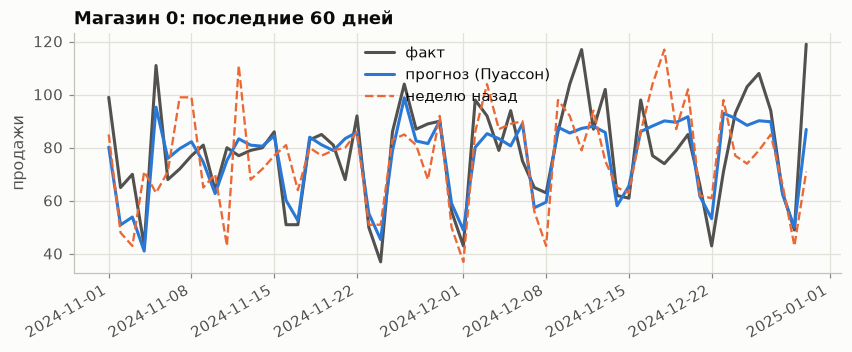

In [7]:
gain = m_po.booster_.feature_importance("gain")
print("   топ-5 по выигрышу: " + ", ".join(f for f, _ in sorted(zip(F, gain), key=lambda t: -t[1])[:5]))
plotting.use_course_style()
shop = te["магазин"] == te["магазин"].cat.categories[0]
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(te.loc[shop, "дата"], te.loc[shop, "продажи"], color=plotting.ROLE["data"], lw=2, label="факт")
ax.plot(te.loc[shop, "дата"], p_po[shop.to_numpy()], color=plotting.ROLE["model"], lw=2, label="прогноз (Пуассон)")
ax.plot(te.loc[shop, "дата"], te.loc[shop, "лаг_7"], color=plotting.ROLE["tree"], lw=1.5, ls="--", label="неделю назад")
ax.set(title="Магазин 0: последние 60 дней", ylabel="продажи")
ax.legend()
fig.autofmt_xdate()
ex.finish(fig, "23_store_forecast")

## Этап 7. Выводы

In [8]:
ex.note("""Бустинг не «понимает» время: всё знание о прошлом нужно явно положить в признаки.
Горизонт определяет минимальный лаг; разбиение — только по времени; база — наивный прогноз.""")
ex.done()

> ▸ **Вывод.** Бустинг не «понимает» время: всё знание о прошлом нужно явно положить в признаки. Горизонт определяет минимальный лаг; разбиение — только по времени; база — наивный прогноз.

Готово за 6.7 с


## Попробуйте сами

Измените код в ячейках выше и выполните их заново:

1. Сделайте горизонт 14 дней (лаги от 14, средние со сдвигом 14) — насколько вырастет WAPE?
2. Добавьте признаки «промо вчера» и «промо завтра».
3. Обучите отдельную модель для каждого типа магазина и сравните с общей.

## Что дальше

- **Теория в курсе:** [1.4 «Смещение и разброс»](../../../lessons/lesson_1_4/README.md) (валидация), [10 «Данные»](../../../lessons/lesson_10/README.md), [13.3 «Эксплуатация»](../../../lessons/lesson_13_3/README.md).
- **Предыдущий пример:** [22. Миллион строк: скорость обучения и прогноза, память, потоки](22_million_rows_speed.ipynb)
- **Следующий пример:** [24. Ранжирование поисковой выдачи: 5000 запросов, ~150 000 пар «запрос — документ»](24_learning_to_rank.ipynb)
- **Все примеры:** [examples/README.md](../../README.md)